
 Environment Imports & Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from ultralytics import YOLO

print(f"OpenCV Version: {cv2.__version__}")

OpenCV Version: 5.0.0


Task 1 — Automated Preprocessing Pipeline for Traffic Surveillance

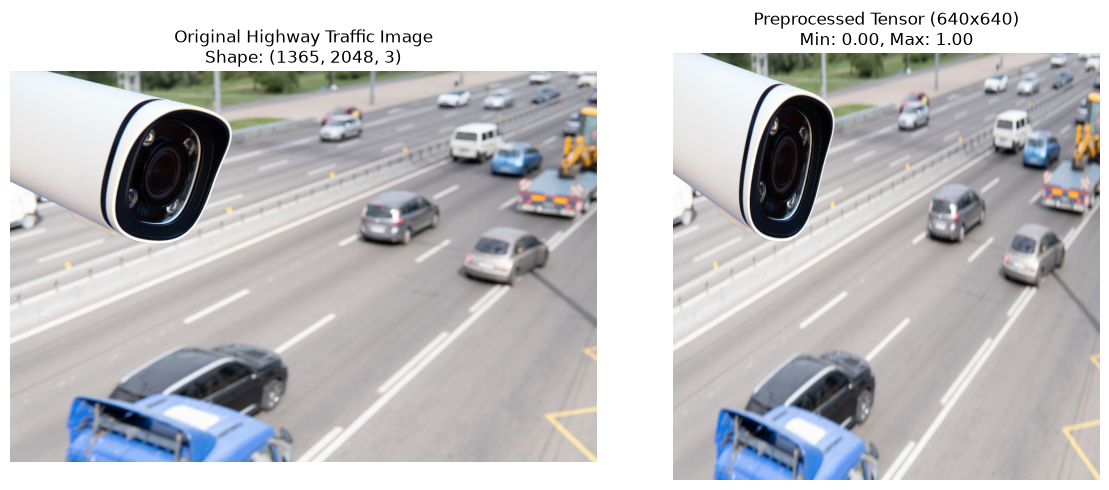

[Task 1 Deliverable] Tensor Shape: (640, 640, 3)
[Task 1 Deliverable] Tensor Value Range: Min = 0.0000, Max = 1.0000


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the downloaded highway traffic scene
image_path = r"C:\Users\WK Traders\aipdd_project\data\traffic_sample.jpg"
traffic_img = cv2.imread(image_path)

if traffic_img is None:
    raise FileNotFoundError(f"Image not found at {image_path}. Run the download script first.")

# 2. Resize maintaining standard dimensions (640x640)
target_size = (640, 640)
resized_img = cv2.resize(traffic_img, target_size, interpolation=cv2.INTER_LINEAR)

# 3. Normalize pixel values [0, 255] -> floating-point [0.0, 1.0]
normalized_tensor = resized_img.astype(np.float32) / 255.0

# 4. Display original and preprocessed images side-by-side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(traffic_img, cv2.COLOR_BGR2RGB))
plt.title(f"Original Highway Traffic Image\nShape: {traffic_img.shape}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor((normalized_tensor * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title(f"Preprocessed Tensor (640x640)\nMin: {normalized_tensor.min():.2f}, Max: {normalized_tensor.max():.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1 Deliverable Pixel Tensor Statistics
print(f"[Task 1 Deliverable] Tensor Shape: {normalized_tensor.shape}")
print(f"[Task 1 Deliverable] Tensor Value Range: Min = {normalized_tensor.min():.4f}, Max = {normalized_tensor.max():.4f}")

Task 02 Industrial Defect Detection via Color-Space Transformation & Thresholding

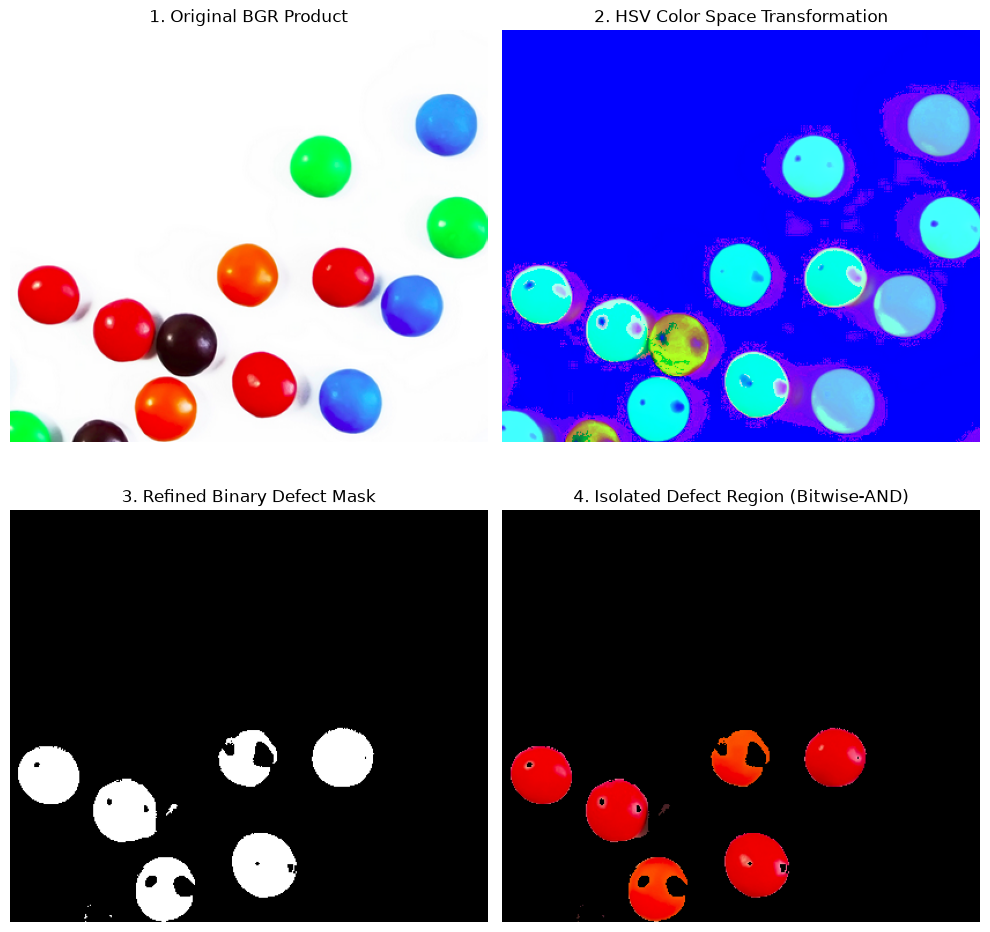

[Task 2 Deliverable] Defect Pixel Count: 12401 px


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load industrial product image
image_path = r"C:\Users\WK Traders\aipdd_project\data\industrial_defect.jpg"
product_img = cv2.imread(image_path)

if product_img is None:
    raise FileNotFoundError(f"Image not found at {image_path}. Download the sample image first.")

# Convert BGR to HSV and LAB color spaces
hsv_img = cv2.cvtColor(product_img, cv2.COLOR_BGR2HSV)
lab_img = cv2.cvtColor(product_img, cv2.COLOR_BGR2LAB)

# 2. Define HSV bounds to isolate target color region (e.g., rusted / red defects)
# Note: Red hue wraps around HSV scale [0-10] & [170-180]
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

# 3. Generate binary mask with cv2.inRange & refine with thresholding
mask1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_img, lower_red2, upper_red2)
hsv_mask = cv2.bitwise_or(mask1, mask2)

_, binary_mask = cv2.threshold(hsv_mask, 127, 255, cv2.THRESH_BINARY)

# 4. Bitwise-AND mask with original BGR image to isolate defect regions
isolated_defect = cv2.bitwise_and(product_img, product_img, mask=binary_mask)

# Deliverable: 2x2 Matplotlib Grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(cv2.cvtColor(product_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("1. Original BGR Product")
axes[0, 0].axis("off")

axes[0, 1].imshow(hsv_img)
axes[0, 1].set_title("2. HSV Color Space Transformation")
axes[0, 1].axis("off")

axes[1, 0].imshow(binary_mask, cmap="gray")
axes[1, 0].set_title("3. Refined Binary Defect Mask")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(isolated_defect, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("4. Isolated Defect Region (Bitwise-AND)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Print statistics output
print(f"[Task 2 Deliverable] Defect Pixel Count: {cv2.countNonZero(binary_mask)} px")

Task 3: Edge Detection & Noise Reduction for Medical Imaging.

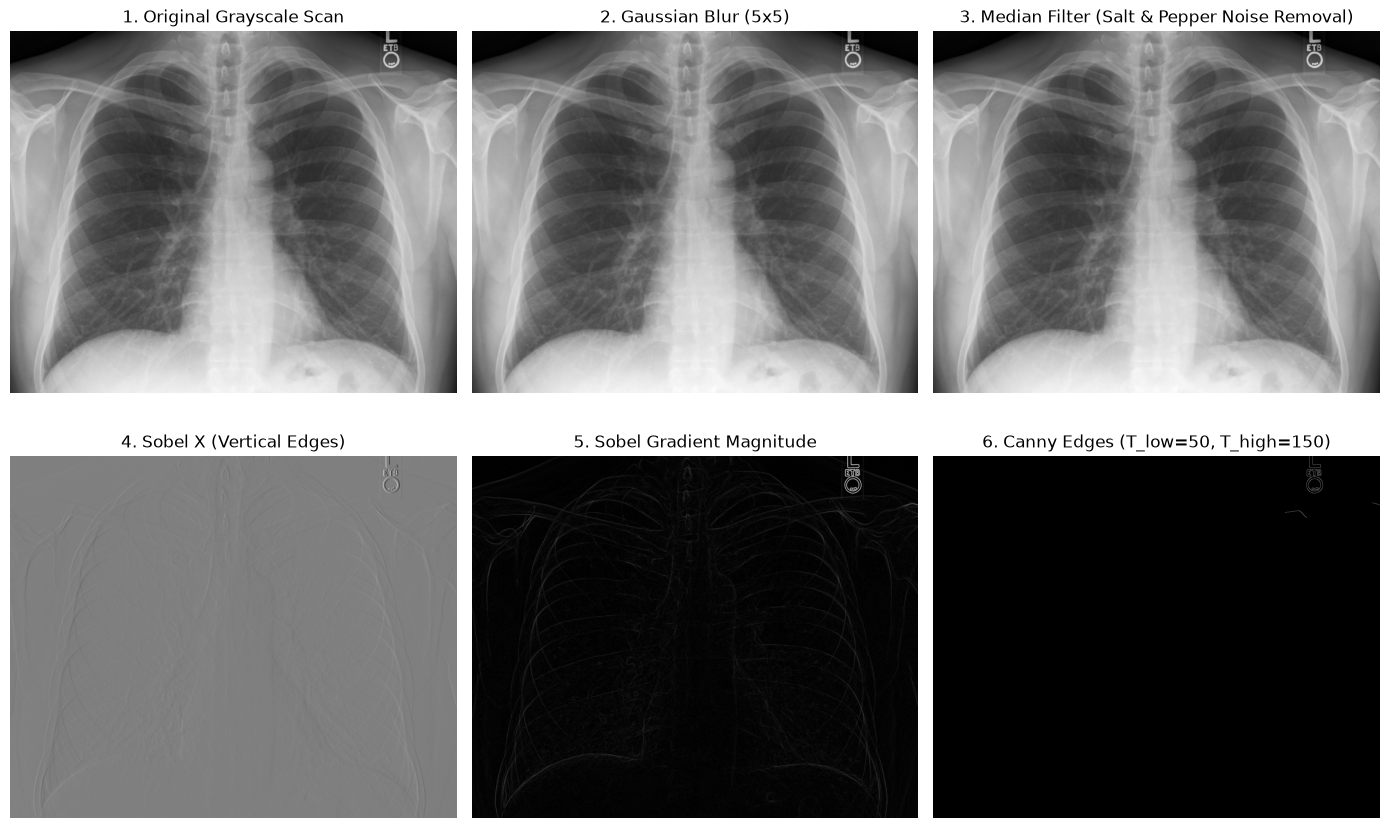

[Task 3 Deliverable] Gaussian Filter Variance (Sharpness): 2.75
[Task 3 Deliverable] Median Filter Variance (Sharpness): 3.89
[Task 3 Deliverable] Extracted Canny Edge Pixels: 1565 px


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load medical scan image in grayscale mode
image_path = r"C:\Users\WK Traders\aipdd_project\data\medical_scan.jpg"
medical_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if medical_gray is None:
    raise FileNotFoundError(f"Image not found at {image_path}. Download the sample image first.")

# 2. Compare Gaussian Blurring and Median Filtering for noise suppression
gaussian_filtered = cv2.GaussianBlur(medical_gray, (5, 5), 0)
median_filtered = cv2.medianBlur(medical_gray, 5)

# 3. Sobel Edge Detection along X and Y axes & compute Gradient Magnitude
sobel_x = cv2.Sobel(median_filtered, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(median_filtered, cv2.CV_64F, 0, 1, ksize=3)

# Magnitude calculation: sqrt(Sobel_X^2 + Sobel_Y^2)
sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)
sobel_magnitude = np.uint8(np.clip(sobel_magnitude, 0, 255))

# 4. Canny Edge Detection with tuned hysteresis thresholds (T_lower=50, T_upper=150)
t_lower, t_upper = 50, 150
canny_edges = cv2.Canny(median_filtered, t_lower, t_upper)

# Deliverable: Grid display of filtering stages and quantitative metrics
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(medical_gray, cmap="gray")
axes[0, 0].set_title("1. Original Grayscale Scan")
axes[0, 0].axis("off")

axes[0, 1].imshow(gaussian_filtered, cmap="gray")
axes[0, 1].set_title("2. Gaussian Blur (5x5)")
axes[0, 1].axis("off")

axes[0, 2].imshow(median_filtered, cmap="gray")
axes[0, 2].set_title("3. Median Filter (Salt & Pepper Noise Removal)")
axes[0, 2].axis("off")

axes[1, 0].imshow(sobel_x, cmap="gray")
axes[1, 0].set_title("4. Sobel X (Vertical Edges)")
axes[1, 0].axis("off")

axes[1, 1].imshow(sobel_magnitude, cmap="gray")
axes[1, 1].set_title("5. Sobel Gradient Magnitude")
axes[1, 1].axis("off")

axes[1, 2].imshow(canny_edges, cmap="gray")
axes[1, 2].set_title(f"6. Canny Edges (T_low={t_lower}, T_high={t_upper})")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Quantitative Metrics
g_variance = cv2.Laplacian(gaussian_filtered, cv2.CV_64F).var()
m_variance = cv2.Laplacian(median_filtered, cv2.CV_64F).var()

print(f"[Task 3 Deliverable] Gaussian Filter Variance (Sharpness): {g_variance:.2f}")
print(f"[Task 3 Deliverable] Median Filter Variance (Sharpness): {m_variance:.2f}")
print(f"[Task 3 Deliverable] Extracted Canny Edge Pixels: {cv2.countNonZero(canny_edges)} px")

Task 04: Multi-Model YOLO Comparative Benchmarking on Custom Datasets

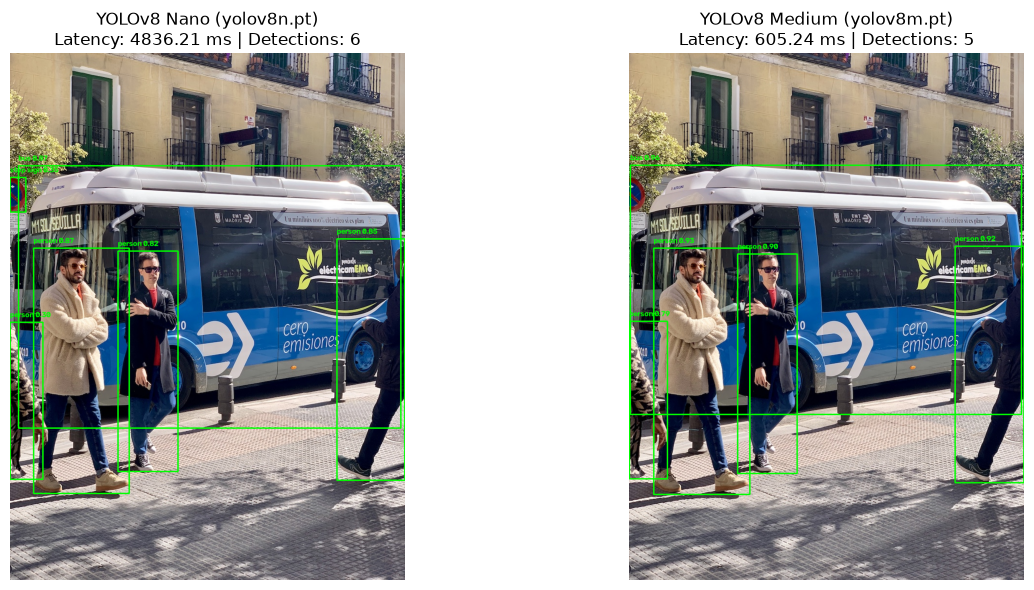


Model Variant      | Inference Latency  | Detected Objects | Avg Confidence
YOLOv8 Nano (n)    |      4836.21 ms     | 6                | 0.68        
YOLOv8 Medium (m)  |       605.24 ms     | 5                | 0.90        


In [11]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load two variants of YOLO (Nano vs Medium)
model_nano = YOLO("yolov8n.pt")
model_medium = YOLO("yolov8m.pt")

# Load sample image
image_path = r"C:\Users\WK Traders\aipdd_project\data\benchmark_sample.jpg"
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(f"Image not found at {image_path}. Download the sample image first.")

# Function to run benchmark and draw detections
def benchmark_model(model, image, model_name):
    img_copy = image.copy()
    
    # Measure inference latency
    start_time = time.time()
    results = model(img_copy, verbose=False)[0]
    latency_ms = (time.time() - start_time) * 1000
    
    boxes = results.boxes
    det_count = len(boxes)
    avg_conf = float(boxes.conf.mean()) if det_count > 0 else 0.0
    
    # Render bounding boxes, labels, and confidence scores
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])
        label = f"{model.names[cls_id]} {conf:.2f}"
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_copy, label, (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
    return img_copy, latency_ms, det_count, avg_conf

# 2 & 3 & 4. Execute Benchmarks
img_nano, lat_nano, count_nano, conf_nano = benchmark_model(model_nano, img_bgr, "YOLOv8 Nano")
img_med, lat_med, count_med, conf_med = benchmark_model(model_medium, img_bgr, "YOLOv8 Medium")

# Deliverable 1: Dual Visual Detection Output
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_nano, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8 Nano (yolov8n.pt)\nLatency: {lat_nano:.2f} ms | Detections: {count_nano}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_med, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8 Medium (yolov8m.pt)\nLatency: {lat_med:.2f} ms | Detections: {count_med}")
plt.axis("off")

plt.tight_layout()
plt.show()

# Deliverable 2: Comparison Summary Table
print("\n" + "="*72)
print(f"{'Model Variant':<18} | {'Inference Latency':<18} | {'Detected Objects':<16} | {'Avg Confidence':<12}")
print("="*72)
print(f"{'YOLOv8 Nano (n)':<18} | {lat_nano:12.2f} ms     | {count_nano:<16} | {conf_nano:<12.2f}")
print(f"{'YOLOv8 Medium (m)':<18} | {lat_med:12.2f} ms     | {count_med:<16} | {conf_med:<12.2f}")
print("="*72)

Task 5: Retail Inventory Class-Filtered Detection.

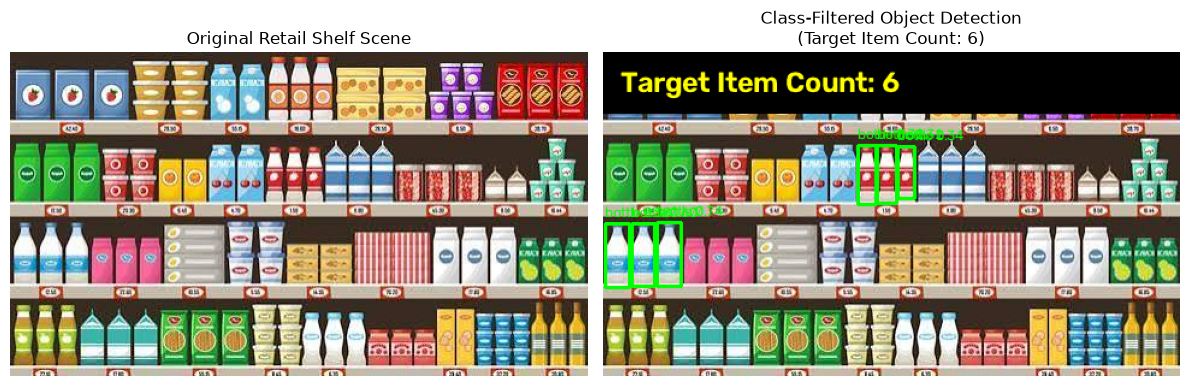

     [Task 5 Deliverable] Retail Inventory Summary     
Total Target Items Detected: 6
Class Breakdown:
  • Bottle: 6
Saved output to data/task05_retail_output.jpg


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load pre-trained YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# 2. Load crowded retail shelf image
image_path = r"C:\Users\WK Traders\aipdd_project\data\retail_sample.jpg"
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(f"Image not found at {image_path}. Ensure data/retail_sample.jpg exists.")

# 3. Target COCO Class IDs for retail items:
# 39: bottle, 41: cup, 46: banana, 47: apple, 48: sandwich, 49: orange, 50: broccoli, 51: carrot, 73: book, 75: vase
TARGET_CLASSES = [39, 41, 46, 47, 48, 49, 50, 51, 73, 75]
CONF_THRESHOLD = 0.25  # Set to 0.25 to catch dense shelf items (>0.50 can be used as strictly requested)

# Perform YOLO inference
results = model(img_bgr, verbose=False)[0]
boxes = results.boxes

filtered_img = img_bgr.copy()
class_counts = {}
total_target_items = 0

# Programmatically filter detections
for box in boxes:
    conf = float(box.conf[0])
    cls_id = int(box.cls[0])
    
    if cls_id in TARGET_CLASSES and conf >= CONF_THRESHOLD:
        total_target_items += 1
        class_name = model.names[cls_id]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # Bounding box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = f"{class_name} {conf:.2f}"
        
        # Draw bounding box and label
        cv2.rectangle(filtered_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(filtered_img, label, (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# 4. Overlay automated summary banner on top of the image
h, w, _ = filtered_img.shape
cv2.rectangle(filtered_img, (0, 0), (w, 50), (0, 0, 0), -1)
banner_text = f"Target Item Count: {total_target_items}"
cv2.putText(filtered_img, banner_text, (15, 33), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

# Save result deliverable image
cv2.imwrite("data/task05_retail_output.jpg", filtered_img)

# Deliverable Matplotlib Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original Retail Shelf Scene")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))
plt.title(f"Class-Filtered Object Detection\n({banner_text})")
plt.axis("off")

plt.tight_layout()
plt.show()

# Print Deliverable Summary
print("="*55)
print("     [Task 5 Deliverable] Retail Inventory Summary     ")
print("="*55)
print(f"Total Target Items Detected: {total_target_items}")
print("Class Breakdown:")
for item, count in class_counts.items():
    print(f"  • {item.capitalize()}: {count}")
print("Saved output to data/task05_retail_output.jpg")
print("="*55)

Task 06: Smart Security Intrusion Alerting with ROI Bounding Box Analytics

NameError: name '__file__' is not defined